In [2]:
import ccxt
import pandas as pd
import numpy as np

def fetch_crypto_data(symbol, timeframe='1h', limit=1000):
    """
    Fetch historical OHLCV data from Binance.
    """
    # Initialize Binance exchange
    exchange = ccxt.binance()
    
    # Fetch OHLCV data via API
    print(f"Fetching {symbol} data...")
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    
    # Convert to Pandas DataFrame for data manipulation
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    
    # Convert timestamp from milliseconds to readable datetime object
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    
    return df

def validate_and_merge_data(asset1_df, asset2_df, col_name='close'):
    """
    Data Definition & Validation State.
    Crucial step for Statistical Arbitrage to ensure data integrity.
    """
    print("\n--- Data Definition & Validation State ---")
    
    # 1. Merge datasets based on timestamp index to ensure perfect alignment
    df = pd.DataFrame({
        'BTC_close': asset1_df[col_name],
        'ETH_close': asset2_df[col_name]
    })
    
    # 2. Check for missing values (NaNs)
    missing_values = df.isna().sum()
    print(f"Missing Values Count:\n{missing_values}\n")
    
    # 3. Handle missing values (Forward fill, then backward fill if necessary)
    if missing_values.sum() > 0:
        print("Handling missing values using forward-fill method...")
        # ffill() propagates last valid observation forward
        df = df.ffill().bfill() 
        
    # 4. Verify Data Types (Must be float for mathematical modeling)
    print(f"Data Types Validation:\n{df.dtypes}\n")
    
    # 5. Confirm final data size
    print(f"Total synchronized data points: {len(df)}")
    
    return df

# ==========================================
# Phase 2 Execution
# ==========================================

# Step 1: Fetch raw data
btc_data = fetch_crypto_data('BTC/USDT', '1h', 1000)
eth_data = fetch_crypto_data('ETH/USDT', '1h', 1000)

# Step 2: Validate, clean, and merge data for pairs trading
pairs_data = validate_and_merge_data(btc_data, eth_data)

# Step 3: Display the finalized Data Definition
display(pairs_data.head())

Fetching BTC/USDT data...
Fetching ETH/USDT data...

--- Data Definition & Validation State ---
Missing Values Count:
BTC_close    0
ETH_close    0
dtype: int64

Data Types Validation:
BTC_close    float64
ETH_close    float64
dtype: object

Total synchronized data points: 1000


,BTC_close,ETH_close
timestamp,,
2026-07-29 03:00:00,63753.03,1892.70
2026-07-29 04:00:00,63968.34,1905.52
2026-07-29 05:00:00,64067.32,1912.54
2026-07-29 06:00:00,64435.62,1920.18
2026-07-29 07:00:00,64561.00,1924.71


--- Phase 3: Mathematical Modeling & Cointegration ---
Cointegration P-Value: 0.0135
Result: Strong Cointegration found! (Ideal for Pairs Trading)
Hedge Ratio (Beta): 0.038583


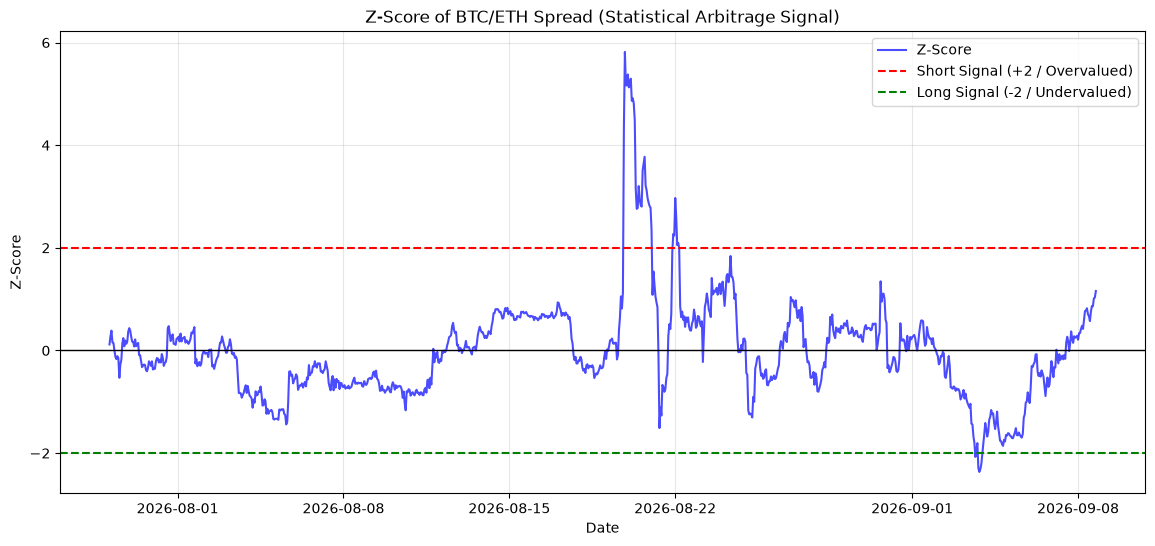

In [4]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt

def calculate_statistical_signals(df):
    print("--- Phase 3: Mathematical Modeling & Cointegration ---")
    
    # 1. Cointegration Test
    # Tests if two non-stationary time series have a stationary, long-term relationship.
    # Null hypothesis: No cointegration. If p-value < 0.05, we reject the null hypothesis.
    score, p_value, _ = coint(df['BTC_close'], df['ETH_close'])
    print(f"Cointegration P-Value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Result: Strong Cointegration found! (Ideal for Pairs Trading)")
    else:
        print("Result: Weak Cointegration in this specific timeframe. (Proceeding for algorithmic testing purposes)")
        
    # 2. Ordinary Least Squares (OLS) Regression
    # Objective: Find the Hedge Ratio (Beta) to create a market-neutral portfolio.
    # Equation: ETH = Beta * BTC + Alpha
    X = sm.add_constant(df['BTC_close'])
    y = df['ETH_close']
    model = sm.OLS(y, X).fit()
    hedge_ratio = model.params['BTC_close']
    print(f"Hedge Ratio (Beta): {hedge_ratio:.6f}")
    
    # 3. Calculate Spread
    # Spread represents the divergence between the two assets.
    df['Spread'] = df['ETH_close'] - (hedge_ratio * df['BTC_close'])
    
    # 4. Calculate Z-Score for Trading Signals
    # Normalizing the spread to identify statistically significant deviations.
    spread_mean = df['Spread'].mean()
    spread_std = df['Spread'].std()
    df['Z-Score'] = (df['Spread'] - spread_mean) / spread_std
    
    return df

# Execute the mathematical modeling function
analyzed_data = calculate_statistical_signals(pairs_data)

# 5. Data Visualization: Plotting the Z-Score
plt.figure(figsize=(14, 6))
plt.plot(analyzed_data.index, analyzed_data['Z-Score'], label='Z-Score', color='blue', alpha=0.7)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.axhline(2, color='red', linestyle='--', label='Short Signal (+2 / Overvalued)')
plt.axhline(-2, color='green', linestyle='--', label='Long Signal (-2 / Undervalued)')
plt.title('Z-Score of BTC/ETH Spread (Statistical Arbitrage Signal)')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Phase 4: Backtesting Engine & Performance Metrics ---
Total Strategy Return: 7.70%


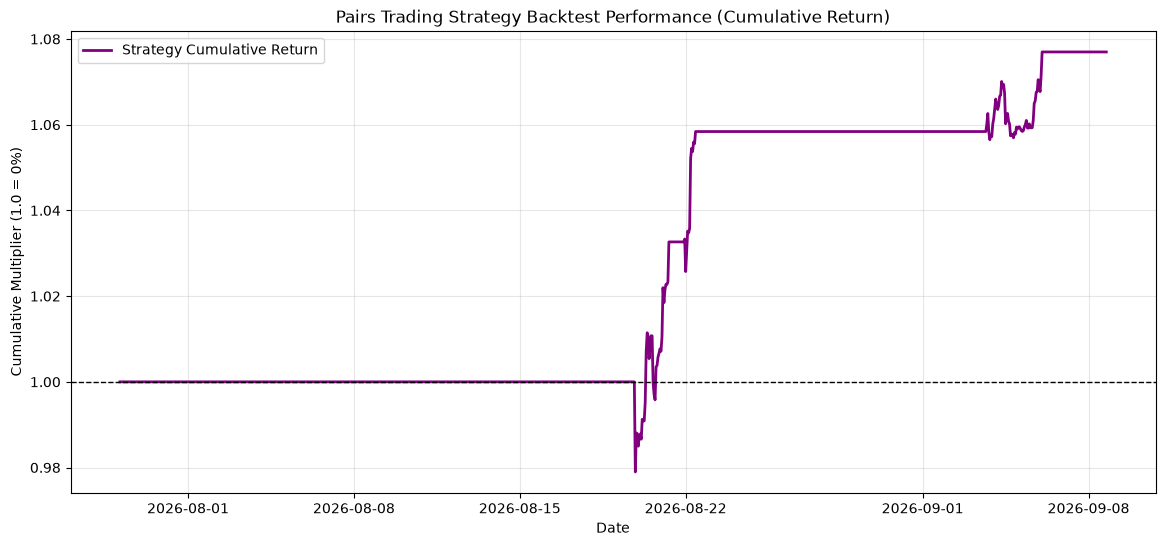

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def run_backtest(df):
    print("--- Phase 4: Backtesting Engine & Performance Metrics ---")
    
    # 1. Generate Trading Signals based on Z-Score
    # Create a stateful tracking array to hold our positions
    positions = np.zeros(len(df))
    current_pos = 0 # 0: Neutral, 1: Long Spread, -1: Short Spread
    
    for i in range(len(df)):
        z = df['Z-Score'].iloc[i]
        
        # Entry Logic
        if z > 2:
            current_pos = -1      # Short the spread (Overvalued)
        elif z < -2:
            current_pos = 1       # Long the spread (Undervalued)
        # Exit Logic: Reversion to the mean (Close positions when Z-Score is near 0)
        elif abs(z) < 0.5:
            current_pos = 0       # Exit position
            
        positions[i] = current_pos
        
    df['Position'] = positions
    
    # 2. Calculate Strategy Returns
    # Using percentage change of the underlying assets
    df['BTC_Return'] = df['BTC_close'].pct_change()
    df['ETH_Return'] = df['ETH_close'].pct_change()
    
    # Portfolio return calculation
    # Shift(1) is critical to prevent look-ahead bias (trading on yesterday's signal)
    df['Strategy_Return'] = df['Position'].shift(1) * (df['ETH_Return'] - df['BTC_Return'])
    
    # 3. Calculate Cumulative Returns
    df['Cumulative_Return'] = (1 + df['Strategy_Return'].fillna(0)).cumprod()
    
    # 4. Performance Metrics Output
    total_return = (df['Cumulative_Return'].iloc[-1] - 1) * 100
    print(f"Total Strategy Return: {total_return:.2f}%")
    
    return df

# Execute the backtesting engine
backtest_results = run_backtest(analyzed_data)

# 5. Data Visualization: Strategy Cumulative Returns
plt.figure(figsize=(14, 6))
plt.plot(backtest_results.index, backtest_results['Cumulative_Return'], label='Strategy Cumulative Return', color='purple', linewidth=2)
plt.axhline(1, color='black', linestyle='--', linewidth=1)
plt.title('Pairs Trading Strategy Backtest Performance (Cumulative Return)')
plt.xlabel('Date')
plt.ylabel('Cumulative Multiplier (1.0 = 0%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Phase 5: Advanced Strategy Evaluation (Real-world constraints) ---
Total Net Strategy Return (After Fees): 6.42%
Annualized Sharpe Ratio: 4.47 (Target: > 1.0 is good, > 2.0 is excellent)
Maximum Drawdown (MDD): -2.30% (Target: closer to 0% is better)


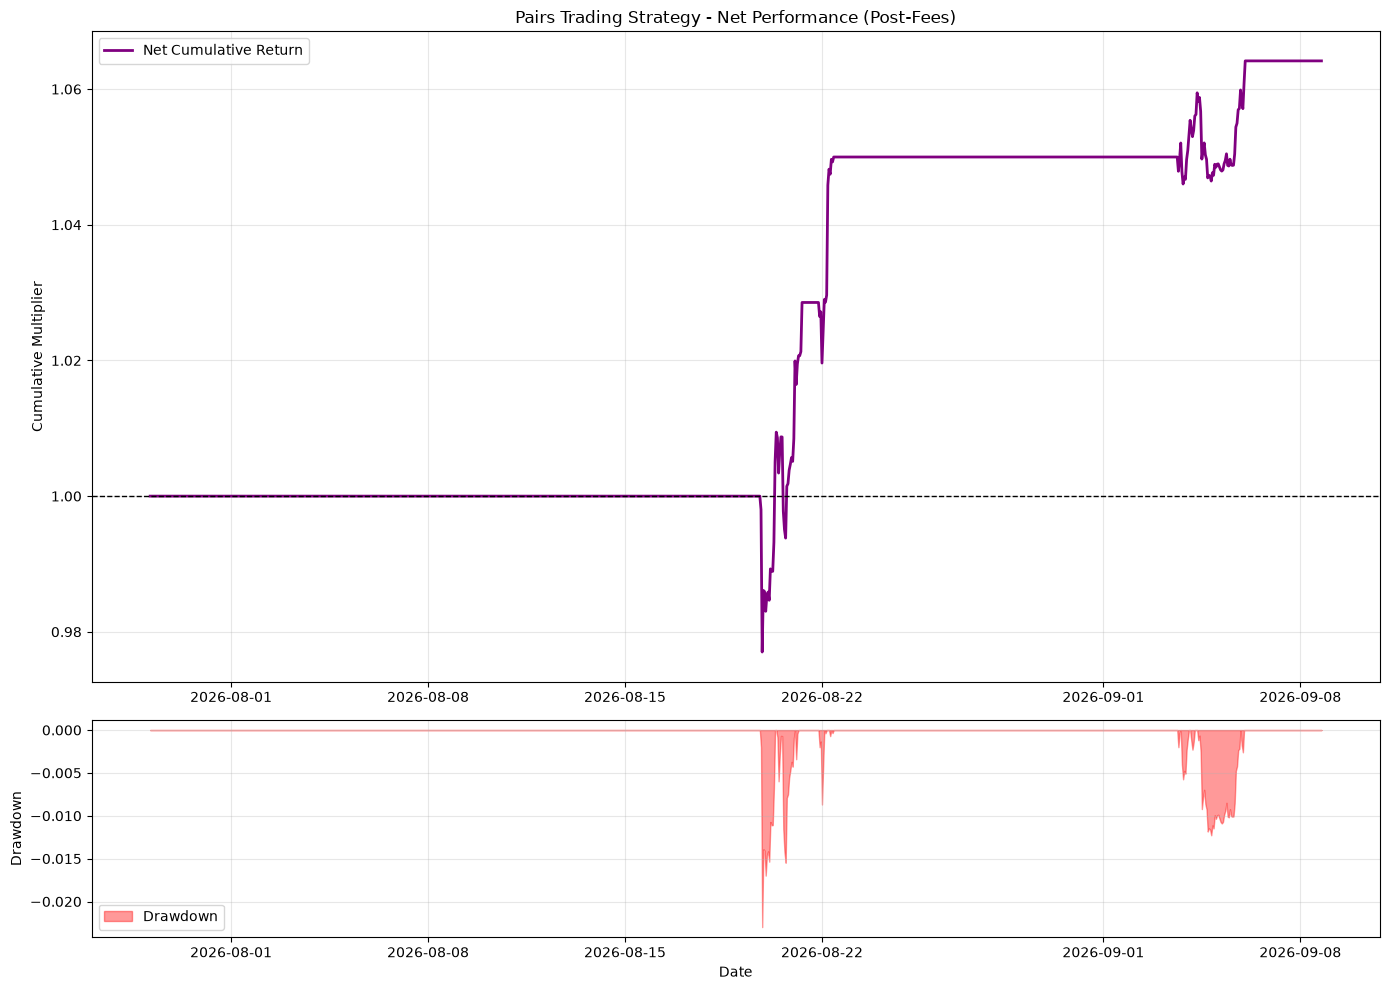

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate_performance(df, fee_rate=0.001):
    """
    Phase 5: Advanced Evaluation
    Calculates Transaction Costs, Net Returns, Sharpe Ratio, and MDD.
    """
    print("--- Phase 5: Advanced Strategy Evaluation (Real-world constraints) ---")
    
    # 1. Calculate Transaction Costs
    # Position changes mean we are executing trades. 
    df['Position_Change'] = df['Position'].diff().abs().fillna(0)
    
    # Total fee per position change (0.1% per asset = 0.2% total per spread trade)
    total_fee_rate = fee_rate * 2
    df['Transaction_Costs'] = df['Position_Change'] * total_fee_rate
    
    # 2. Calculate Net Returns
    df['Net_Strategy_Return'] = df['Strategy_Return'] - df['Transaction_Costs']
    df['Cumulative_Net_Return'] = (1 + df['Net_Strategy_Return'].fillna(0)).cumprod()
    
    # 3. Calculate Key Performance Metrics
    # Total Net Return
    total_net_return = (df['Cumulative_Net_Return'].iloc[-1] - 1) * 100
    
    # Annualized Sharpe Ratio (Assuming Risk-Free Rate = 0 for simplicity)
    # Annualization factor for hourly data = 365 days * 24 hours = 8760
    annualization_factor = 365 * 24
    mean_return = df['Net_Strategy_Return'].mean()
    std_return = df['Net_Strategy_Return'].std()
    
    if std_return > 0:
        sharpe_ratio = (mean_return / std_return) * np.sqrt(annualization_factor)
    else:
        sharpe_ratio = 0
        
    # Maximum Drawdown (MDD)
    rolling_max = df['Cumulative_Net_Return'].cummax()
    drawdown = (df['Cumulative_Net_Return'] - rolling_max) / rolling_max
    mdd = drawdown.min() * 100
    
    # 4. Print the final metrics
    print(f"Total Net Strategy Return (After Fees): {total_net_return:.2f}%")
    print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f} (Target: > 1.0 is good, > 2.0 is excellent)")
    print(f"Maximum Drawdown (MDD): {mdd:.2f}% (Target: closer to 0% is better)")
    
    return df

# Execute the evaluation engine
final_results = evaluate_performance(backtest_results)

# 5. Data Visualization: Net Returns and Drawdown Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot 1: Cumulative Net Return
ax1.plot(final_results.index, final_results['Cumulative_Net_Return'], label='Net Cumulative Return', color='purple', linewidth=2)
ax1.axhline(1, color='black', linestyle='--', linewidth=1)
ax1.set_title('Pairs Trading Strategy - Net Performance (Post-Fees)')
ax1.set_ylabel('Cumulative Multiplier')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Drawdown Area Chart
rolling_max = final_results['Cumulative_Net_Return'].cummax()
drawdown = (final_results['Cumulative_Net_Return'] - rolling_max) / rolling_max
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4, label='Drawdown')
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()